In [41]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch
from tqdm.auto import tqdm
import torch.nn.functional as F

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.output import*
from lib.cea_lib.data_loader import*


# Conditional Diffusion Model on 1D Wavelet Coefficients

Dans ce notebook, le signal 1D $x_0 \in \mathbb{R}^{32}$ est décomposé en ondelettes de Haar au niveau 1 :
$$x_0 \longmapsto (Ca, Ch).$$

L'objectif n'est plus de conditionner la diffusion par un label discret. On utilise directement l'approximation basse fréquence `Ca` comme condition, et le modèle de diffusion apprend à générer le détail haute fréquence `Ch` :
$$p_\theta(Ch \mid Ca).$$

Cela correspond à une factorisation coarse-to-fine : `Ca` fixe la structure basse fréquence du signal, tandis que la diffusion modélise les composantes fines compatibles avec cette structure.


# Chargement du Dataset RT-CEA

On charge un dataset 2D RT-CEA connu, puis on le prétraite en images `32 x 32`. Pour rester dans un modèle 1D, chaque ligne horizontale de chaque image prétraitée est utilisée comme un signal de taille `SIGNAL_SIZE = 32`.

Les labels physiques chargés depuis le fichier HDF5 sont conservés uniquement comme métadonnées éventuelles. Ils ne sont pas utilisés par le modèle : le conditionnement de la diffusion reste `Ca`, et la variable diffusée reste `Ch`.


In [42]:
N = 50000
SIGNAL_SIZE = 32
DATA_FILE = "../data/RTCEA_bimode.hdf5"

MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)
FORCE_RETRAIN = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Nombre minimal d'images 32x32 nécessaires si chaque ligne devient un signal 1D.
image_number = N // SIGNAL_SIZE

data_raw, labels_raw = load_RTCEA(DATA_FILE)

try:
    data_norm, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=SIGNAL_SIZE,
    )
except ImportError as exc:
    # Fallback si OpenCV n'est pas disponible : crop/mask avec data_preprocessing,
    # puis resize par interpolation PyTorch.
    if "OpenCV" not in str(exc):
        raise
    data_cropped, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=-1,
    )
    data_tensor = torch.as_tensor(data_cropped, dtype=torch.float32)[:, None]
    data_norm = torch.nn.functional.interpolate(
        data_tensor,
        size=(SIGNAL_SIZE, SIGNAL_SIZE),
        mode="bilinear",
        align_corners=False,
    )[:, 0].numpy()

if data_norm.shape[0] == 0:
    raise ValueError("data_preprocessing n'a retourné aucune image. Vérifier le fichier et les critères de crop.")

# Chaque image (32, 32) fournit 32 signaux 1D de longueur 32.
# On limite à N signaux après aplatissement en lignes.
profile_images = data_norm[:image_number]
profiles = profile_images.reshape(-1, SIGNAL_SIZE)[:N]

# Normalisation globale du dataset 1D pour une échelle compatible avec la diffusion gaussienne.
dataset = torch.as_tensor(profiles, dtype=torch.float32)
signal_mean = dataset.mean()
signal_std = dataset.std().clamp_min(1e-8)
dataset = (dataset - signal_mean) / signal_std

grid = torch.linspace(0, 1, SIGNAL_SIZE)
N = dataset.shape[0]

print("data_raw.shape       =", data_raw.shape)
print("data_norm.shape      =", data_norm.shape)
print("profile_images.shape =", profile_images.shape)
print("dataset.shape        =", dataset.shape)
print("mean/std             =", dataset.mean().item(), dataset.std().item())


data_raw.shape       = (1978, 512, 256)
data_norm.shape      = (1445, 32, 32)
profile_images.shape = (1445, 32, 32)
dataset.shape        = torch.Size([46240, 32])
mean/std             = -3.3659095066695954e-08 1.0


In [43]:
# Optionnel : pour changer le type de profil 1D, remplacer l'extraction par lignes ci-dessus
# par des colonnes, une moyenne verticale, ou une coupe choisie physiquement.


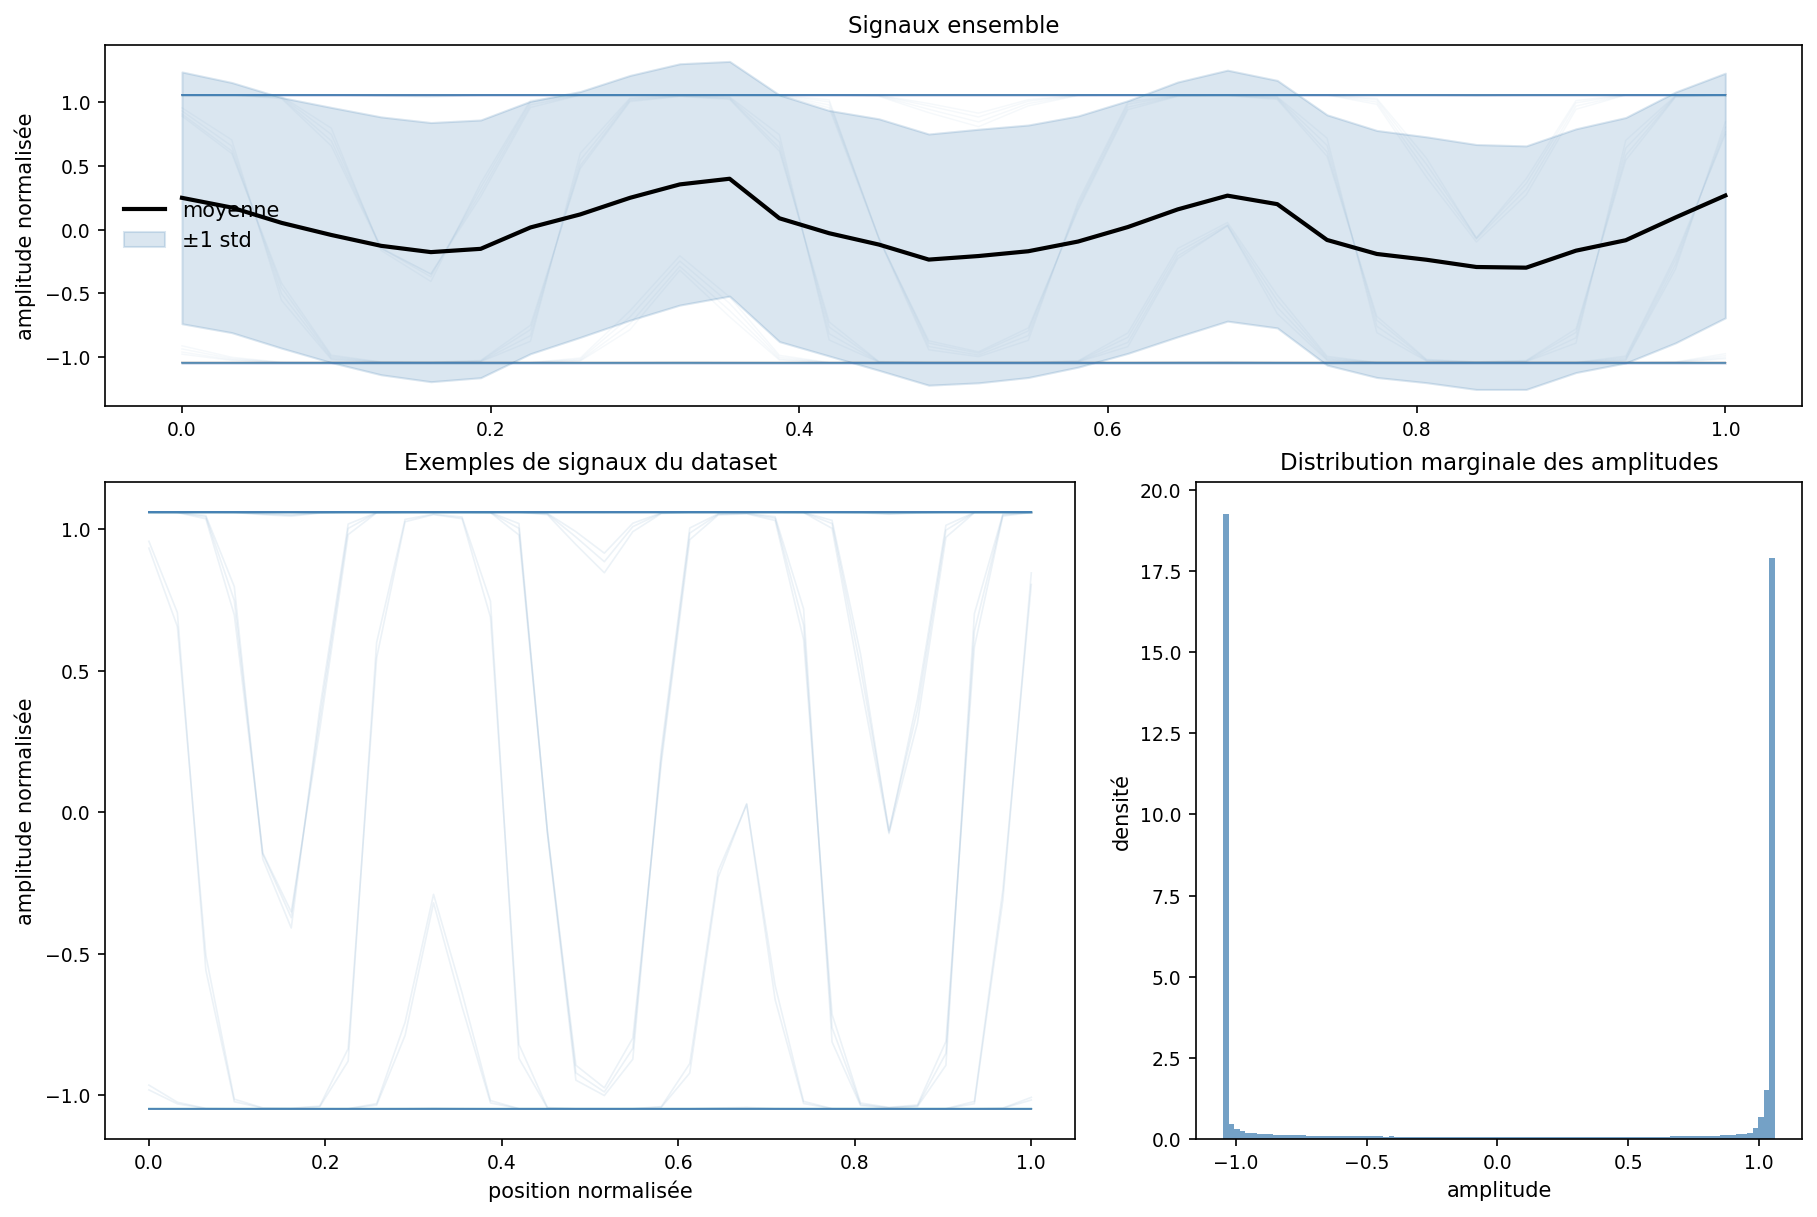

In [44]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.1, 1.0, 1.0],
    width_ratios=[1.6, 1.0],
)

ax_all = fig.add_subplot(gs[0, :])
ax_examples = fig.add_subplot(gs[1:, 0], sharex=ax_all)
ax_dist = fig.add_subplot(gs[1:, 1])

mean_signal = dataset.mean(dim=0)
std_signal = dataset.std(dim=0)

ax_all.plot(grid, dataset[:120].T, color="steelblue", alpha=0.05, linewidth=0.7)
ax_all.plot(grid, mean_signal, color="black", linewidth=2, label="moyenne")
ax_all.fill_between(
    grid.numpy(),
    (mean_signal - std_signal).numpy(),
    (mean_signal + std_signal).numpy(),
    color="steelblue",
    alpha=0.2,
    label="±1 std",
)
ax_all.set_title("Signaux ensemble")
ax_all.set_ylabel("amplitude normalisée")
ax_all.legend(frameon=False)

ax_examples.plot(grid, dataset[:80].T, color="steelblue", alpha=0.10, linewidth=0.8)
ax_examples.set_title("Exemples de signaux du dataset")
ax_examples.set_xlabel("position normalisée")
ax_examples.set_ylabel("amplitude normalisée")

ax_dist.hist(dataset.flatten(), bins=100, density=True, color="steelblue", alpha=0.75)
ax_dist.set_title("Distribution marginale des amplitudes")
ax_dist.set_xlabel("amplitude")
ax_dist.set_ylabel("densité")

plt.show()


## Décomposition ondelette multi-échelle 1D

On utilise une factorisation hiérarchique Haar à trois niveaux. Pour un signal de taille 32 :

$$x \rightarrow (Ca_1, Ch_1), \quad Ca_1 \rightarrow (Ca_2, Ch_2), \quad Ca_2 \rightarrow (Ca_3, Ch_3).$$

Le modèle génératif devient :

$$p(Ca_3)\,p(Ch_3\mid Ca_3)\,p(Ch_2\mid Ca_2)\,p(Ch_1\mid Ca_1),$$

avec $Ca_2 = W^{-1}(Ca_3, Ch_3)$ et $Ca_1 = W^{-1}(Ca_2, Ch_2)$. Cela évite de conditionner directement tous les détails sur le signal complet : chaque modèle ne voit que l'approximation basse fréquence à son échelle.

In [45]:
import pywt
from torch.utils.data import TensorDataset, DataLoader

WAVELET = "db1"
LEVELS = 3


def wavedec_tensor(signals, wavelet=WAVELET, level=LEVELS):
    """Retourne les coefficients PyWavelets [cA_level, cD_level, ..., cD1] sous forme de tenseurs."""
    if isinstance(signals, torch.Tensor):
        signals_np = signals.detach().cpu().numpy()
        dtype = signals.dtype
    else:
        signals_np = np.asarray(signals)
        dtype = torch.float32

    coeffs_per_sample = [pywt.wavedec(signal, wavelet=wavelet, level=level) for signal in signals_np]
    coeff_blocks = []
    for block_id in range(level + 1):
        coeff_blocks.append(torch.tensor(
            np.stack([sample[block_id] for sample in coeffs_per_sample], axis=0),
            dtype=dtype,
        ))
    return coeff_blocks


def waverec_tensor(coeff_blocks, wavelet=WAVELET, length=None):
    """Reconstruction complète depuis [cA_level, cD_level, ..., cD1]."""
    coeffs_np = [block.detach().cpu().numpy() if isinstance(block, torch.Tensor) else np.asarray(block) for block in coeff_blocks]
    reconstructed = [pywt.waverec([block[i] for block in coeffs_np], wavelet=wavelet) for i in range(coeffs_np[0].shape[0])]
    out = torch.tensor(np.stack(reconstructed, axis=0), dtype=coeff_blocks[0].dtype)
    return out[:, :length] if length is not None else out


def idwt_pair(ca, ch, wavelet=WAVELET):
    """Reconstruction d'une approximation plus fine depuis une paire (Ca_j, Ch_j)."""
    ca_np = ca.detach().cpu().numpy() if isinstance(ca, torch.Tensor) else np.asarray(ca)
    ch_np = ch.detach().cpu().numpy() if isinstance(ch, torch.Tensor) else np.asarray(ch)
    reconstructed = [pywt.waverec([ca_np[i], ch_np[i]], wavelet=wavelet) for i in range(ca_np.shape[0])]
    return torch.tensor(np.stack(reconstructed, axis=0), dtype=ca.dtype if isinstance(ca, torch.Tensor) else torch.float32)


In [46]:
# Coefficients de référence aux trois niveaux.
# wavedec niveau 3 renvoie [Ca3, Ch3, Ch2, Ch1].
Ca3, Ch3, Ch2, Ch1 = wavedec_tensor(dataset, wavelet=WAVELET, level=LEVELS)
Ca3_mean = Ca3.mean(0, keepdim=True)
Ca3_std = Ca3.std(0, keepdim=True)

Ca3_train = (
    Ca3 - Ca3_mean
) / (
    Ca3_std + 1e-8
)

# Approximations intermédiaires reconstruites depuis la hiérarchie exacte.
Ca2 = idwt_pair(Ca3, Ch3, wavelet=WAVELET)
Ca1 = idwt_pair(Ca2, Ch2, wavelet=WAVELET)

reconstructed = waverec_tensor([Ca3, Ch3, Ch2, Ch1], wavelet=WAVELET, length=SIGNAL_SIZE)
reconstruction_error = torch.mean((reconstructed - dataset) ** 2).sqrt()

print("dataset.shape =", dataset.shape)
print("Ca3.shape     =", Ca3.shape, " # modèle non conditionné")
print("Ch3.shape     =", Ch3.shape, " # conditionné par Ca3")
print("Ca2.shape     =", Ca2.shape, " # reconstruction inverse de (Ca3, Ch3)")
print("Ch2.shape     =", Ch2.shape, " # conditionné par Ca2")
print("Ca1.shape     =", Ca1.shape, " # reconstruction inverse de (Ca2, Ch2)")
print("Ch1.shape     =", Ch1.shape, " # conditionné par Ca1")
print("RMSE reconstruction niveau 3 =", reconstruction_error.item())


dataset.shape = torch.Size([46240, 32])
Ca3.shape     = torch.Size([46240, 4])  # modèle non conditionné
Ch3.shape     = torch.Size([46240, 4])  # conditionné par Ca3
Ca2.shape     = torch.Size([46240, 8])  # reconstruction inverse de (Ca3, Ch3)
Ch2.shape     = torch.Size([46240, 8])  # conditionné par Ca2
Ca1.shape     = torch.Size([46240, 16])  # reconstruction inverse de (Ca2, Ch2)
Ch1.shape     = torch.Size([46240, 16])  # conditionné par Ca1
RMSE reconstruction niveau 3 = 1.300635972256714e-07


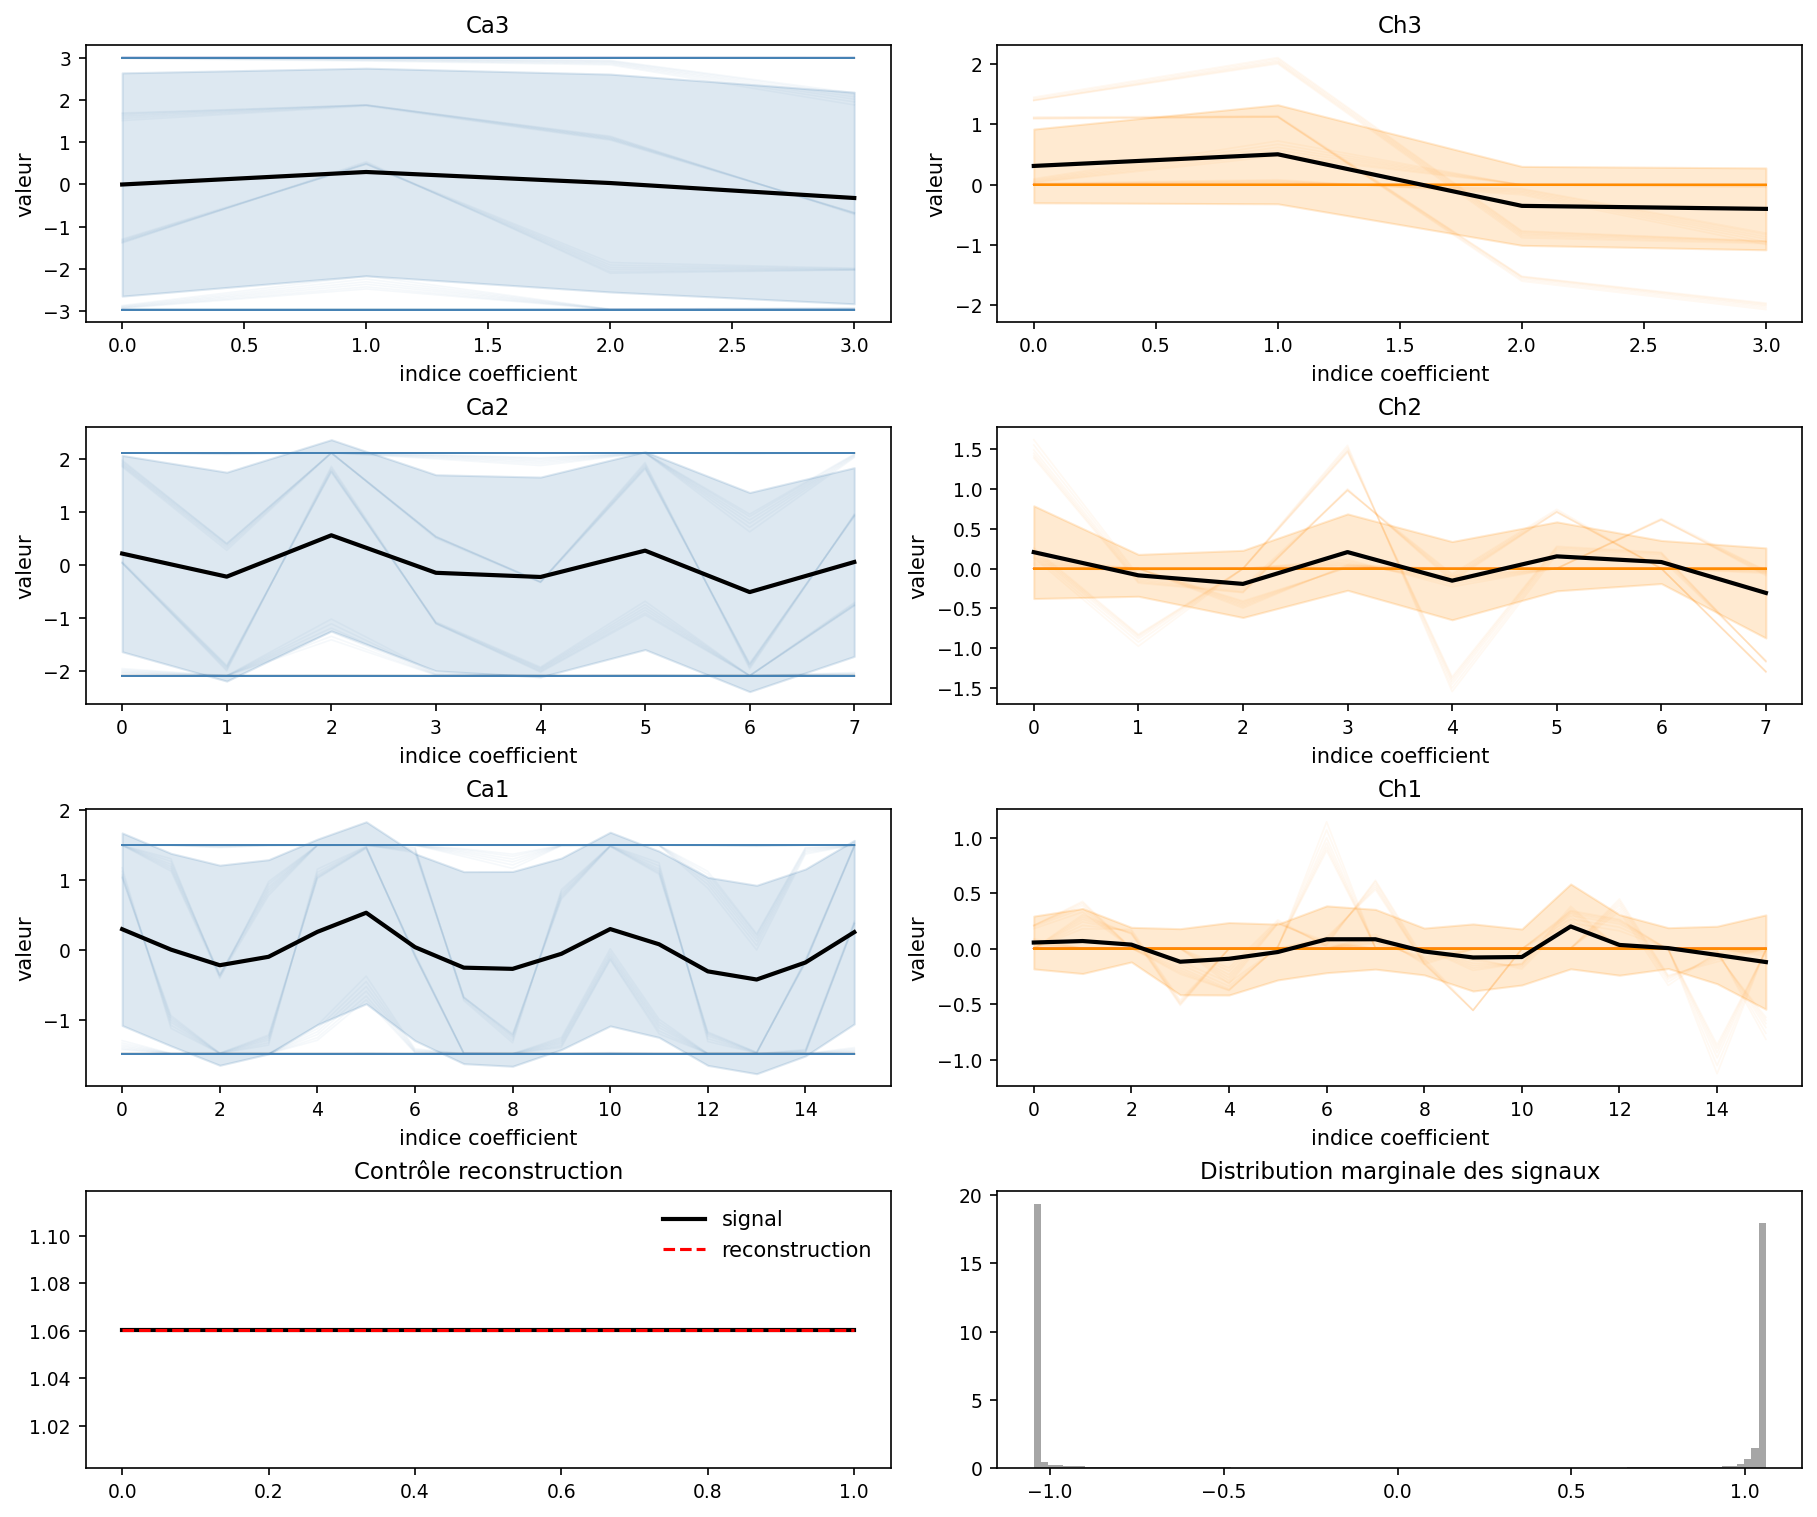

In [47]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), constrained_layout=True)
blocks = [
    (Ca3, "Ca3", "steelblue"),
    (Ch3, "Ch3", "darkorange"),
    (Ca2, "Ca2", "steelblue"),
    (Ch2, "Ch2", "darkorange"),
    (Ca1, "Ca1", "steelblue"),
    (Ch1, "Ch1", "darkorange"),
]

for axis, (block, name, color) in zip(axes.flat[:6], blocks):
    coef_grid = torch.arange(block.shape[1])
    axis.plot(coef_grid, block[:200].T, color=color, alpha=0.05, linewidth=0.8)
    axis.plot(coef_grid, block.mean(dim=0), color="black", linewidth=2)
    axis.fill_between(
        coef_grid.numpy(),
        (block.mean(dim=0) - block.std(dim=0)).numpy(),
        (block.mean(dim=0) + block.std(dim=0)).numpy(),
        color=color,
        alpha=0.18,
    )
    axis.set_title(name)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")

axes.flat[6].plot(grid, dataset[0], color="black", linewidth=2, label="signal")
axes.flat[6].plot(grid, reconstructed[0], color="red", linestyle="--", linewidth=1.5, label="reconstruction")
axes.flat[6].set_title("Contrôle reconstruction")
axes.flat[6].legend(frameon=False)
axes.flat[7].hist(dataset.flatten(), bins=100, density=True, color="gray", alpha=0.7)
axes.flat[7].set_title("Distribution marginale des signaux")
plt.show()


## Diffusion avant

Chaque variable de la cascade utilise le même processus DDPM scalaire par coefficient :

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \quad \epsilon\sim\mathcal{N}(0,I).$$

Le premier modèle apprend $p(Ca_3)$ sans condition. Les modèles suivants apprennent les distributions conditionnelles de détail.

In [ ]:
# Calendrier de bruit explicite.
# TIME_STEPS est la borne maximale ; T est choisi automatiquement comme le
# premier pas pour lequel SNR(t) <= SNR_THRESHOLD.
TIME_STEPS = 200
T_non_conditione = 200
SNR_THRESHOLD = 5
BETA_START = 1e-4
BETA_END = 5e-2


def get_schedule(steps=TIME_STEPS, device=None, dtype=torch.float32):
    if steps < 1 or steps > TIME_STEPS:
        raise ValueError(f"steps doit appartenir à [1, {TIME_STEPS}], reçu {steps}.")

    betas = torch.linspace(
        BETA_START,
        BETA_END,
        TIME_STEPS,
        device=device,
        dtype=dtype,
    )[:steps]
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars


def snr_from_alpha_bar(alpha_bars):
    denominator = (1.0 - alpha_bars).clamp_min(torch.finfo(alpha_bars.dtype).eps)
    return alpha_bars / denominator


def diffusion_steps_for_snr(snr_threshold, steps=TIME_STEPS, device=None, dtype=torch.float32):
    _, _, alpha_bars = get_schedule(steps, device=device, dtype=dtype)
    snrs = snr_from_alpha_bar(alpha_bars)

    if snr_threshold is None:
        return steps, snrs[-1], True

    below_threshold = torch.nonzero(snrs <= snr_threshold, as_tuple=False)
    if len(below_threshold) == 0:
        return steps, snrs[-1], False

    step = int(below_threshold[0].item()) + 1
    return step, snrs[step - 1], True


def q_sample(x0, t, eps=None, steps=TIME_STEPS):
    if eps is None:
        eps = torch.randn_like(x0)

    _, _, alpha_bars = get_schedule(
        steps,
        device=x0.device,
        dtype=x0.dtype,
    )
    alpha_bar_t = alpha_bars[t.long().flatten() - 1].view(-1, 1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return xt, eps


def do_diffusion_until_snr(data, snr_threshold=SNR_THRESHOLD, steps=TIME_STEPS):
    samples = [data]
    xt = data
    stop_step, _, _ = diffusion_steps_for_snr(
        snr_threshold,
        steps=steps,
        device=data.device,
        dtype=data.dtype,
    )
    betas, alphas, _ = get_schedule(
        steps,
        device=data.device,
        dtype=data.dtype,
    )

    for i in range(stop_step):
        xt = torch.sqrt(alphas[i]) * xt + torch.sqrt(betas[i]) * torch.randn_like(xt)
        samples.append(xt)

    return samples, stop_step


# T est maintenant obtenu via la même fonction que la diffusion avant.
_snr_probe, T = do_diffusion_until_snr(Ca3_train[:1], snr_threshold=SNR_THRESHOLD, steps=TIME_STEPS)
del _snr_probe
_, _, alpha_bars_cpu = get_schedule(T)
terminal_alpha_bar = alpha_bars_cpu[-1]
terminal_snr = snr_from_alpha_bar(terminal_alpha_bar)
snr_threshold_reached = bool(terminal_snr <= SNR_THRESHOLD)
print(
    f"T_conditionne = {T}, T_non_conditione = {T_non_conditione}, "
    f"alpha_bar_T = {terminal_alpha_bar.item():.4g}, "
    f"SNR_T = {terminal_snr.item():.4g}, "
    f"SNR_THRESHOLD = {SNR_THRESHOLD:g}, reached = {snr_threshold_reached}"
)


T_conditionne = 31, T_non_conditione = 200, alpha_bar_T = 0.8869, SNR_T = 7.843, SNR_THRESHOLD = 8, reached = True


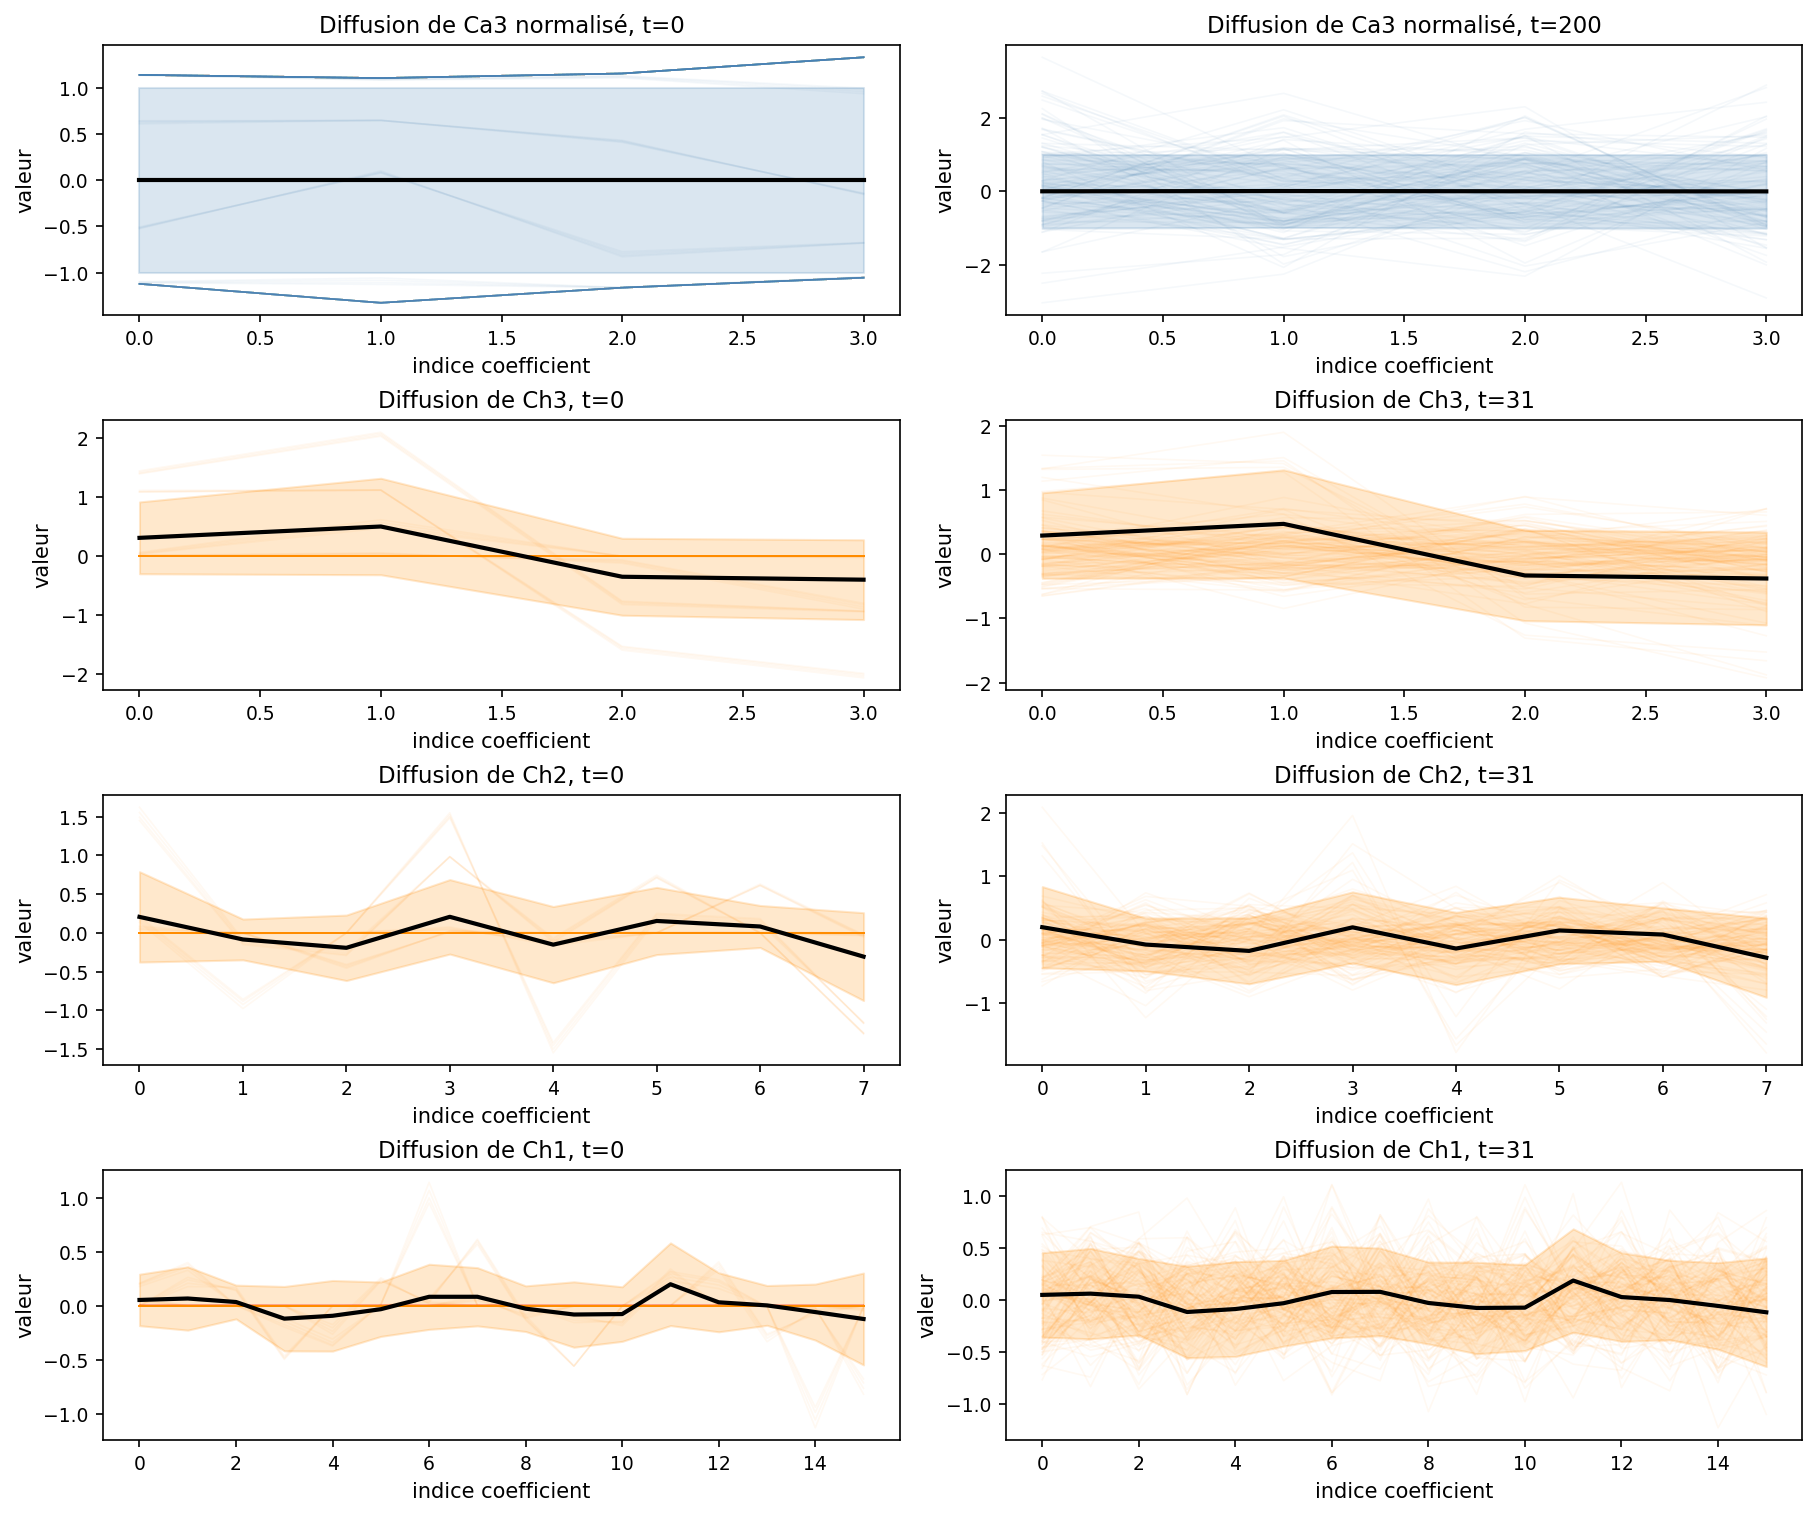

In [73]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), constrained_layout=True)
for row, (block, name, color, steps) in enumerate([
    (Ca3_train, "Ca3 normalisé", "steelblue", T_non_conditione),
    (Ch3, "Ch3", "darkorange", T),
    (Ch2, "Ch2", "darkorange", T),
    (Ch1, "Ch1", "darkorange", T),
]):
    t_final = torch.full((block.shape[0], 1), steps, dtype=torch.long)
    noisy_final, _ = q_sample(block, t_final, steps=steps)
    coef_grid = torch.arange(block.shape[1])

    for col, (time_index, subset) in enumerate([(0, block), (steps, noisy_final)]):
        mean_signal = subset.mean(dim=0)
        std_signal = subset.std(dim=0)
        axes[row, col].plot(coef_grid, subset[:120].T, color=color, alpha=0.05, linewidth=0.8)
        axes[row, col].plot(coef_grid, mean_signal, color="black", linewidth=2)
        axes[row, col].fill_between(
            coef_grid.numpy(),
            (mean_signal - std_signal).numpy(),
            (mean_signal + std_signal).numpy(),
            color=color,
            alpha=0.2,
        )
        axes[row, col].set_title(f"Diffusion de {name}, t={time_index}")
        axes[row, col].set_xlabel("indice coefficient")
        axes[row, col].set_ylabel("valeur")

plt.show()


# Entraînement de la cascade

On entraîne quatre estimateurs de bruit indépendants :

- `eps_model_Ca3` : non conditionné, cible `Ca3` ;
- `eps_model_Ch3` : cible `Ch3`, condition `Ca3` ;
- `eps_model_Ch2` : cible `Ch2`, condition `Ca2` ;
- `eps_model_Ch1` : cible `Ch1`, condition `Ca1`.

La condition utilisée pendant l'entraînement est l'approximation exacte de l'échelle correspondante. Pendant la génération, elle est remplacée par l'approximation générée récursivement, ce qui expose la cascade à une accumulation d'erreur non modélisée explicitement ici.

In [50]:
from pathlib import Path
import torch

CA3_ARCHITECTURE = "conv1d"  # options: "residual_mlp", "conv1d", "mlp"
TIME_EMBED_FREQS = (1.0, 2.0, 4.0, 8.0, 16.0)
MODEL_VERSION_BASE = f"max{TIME_STEPS}_linear_{BETA_START:g}_{BETA_END:g}_timeff{len(TIME_EMBED_FREQS)}"


def time_feature_dim():
    return 1 + 2 * len(TIME_EMBED_FREQS)


def diffusion_time_features(t, T):
    tau = t.to(dtype=torch.float32) / T
    tau = tau.to(device=t.device)
    features = [tau]
    for freq in TIME_EMBED_FREQS:
        arg = torch.pi * freq * tau
        features.append(torch.sin(arg))
        features.append(torch.cos(arg))
    return torch.cat(features, dim=1)


class ResidualBlock(torch.nn.Module):
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.LayerNorm(dim),
            torch.nn.Linear(dim, dim),
            torch.nn.SiLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.net(x)


class ResidualEpsMLP(torch.nn.Module):
    def __init__(self, input_dim, target_dim, hidden_dim=256, blocks=4, dropout=0.05):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.SiLU(),
            *[ResidualBlock(hidden_dim, dropout=dropout) for _ in range(blocks)],
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.Linear(hidden_dim, target_dim),
        )

    def forward(self, features):
        return self.net(features)


class ConvEpsModel(torch.nn.Module):
    """Petit score network 1D. Utile à tester, mais l'inductive bias est faible pour Ca3 de taille 4."""
    def __init__(self, target_dim, context_dim, hidden_dim=96, blocks=3):
        super().__init__()
        self.target_dim = target_dim
        self.context_dim = context_dim

        self.context = torch.nn.Sequential(
            torch.nn.Linear(context_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
        )
        self.in_proj = torch.nn.Conv1d(2, hidden_dim, kernel_size=1)
        self.convs = torch.nn.ModuleList([
            torch.nn.Sequential(
                torch.nn.GroupNorm(8, hidden_dim),
                torch.nn.SiLU(),
                torch.nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
                torch.nn.GroupNorm(8, hidden_dim),
                torch.nn.SiLU(),
                torch.nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            )
            for _ in range(blocks)
        ])
        self.out = torch.nn.Sequential(
            torch.nn.GroupNorm(8, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Conv1d(hidden_dim, 1, kernel_size=1),
        )

    def forward(self, features):
        xt = features[:, :self.target_dim]
        context = features[:, self.target_dim:]
        position = torch.linspace(
            -1.0,
            1.0,
            self.target_dim,
            device=features.device,
            dtype=features.dtype,
        ).expand_as(xt)

        x = torch.stack([xt, position], dim=1)
        h = self.in_proj(x)
        context_bias = self.context(context).unsqueeze(-1)
        h = h + context_bias

        for conv in self.convs:
            h = h + conv(h)

        return self.out(h).squeeze(1)


def make_eps_model(target_dim, condition_dim=0, hidden_dim=128, architecture="mlp"):
    input_dim = target_dim + time_feature_dim() + condition_dim

    if architecture == "mlp":
        return torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, target_dim),
        )

    if architecture == "residual_mlp":
        return ResidualEpsMLP(
            input_dim=input_dim,
            target_dim=target_dim,
            hidden_dim=hidden_dim,
            blocks=4,
            dropout=0.05,
        )

    if architecture == "conv1d":
        return ConvEpsModel(
            target_dim=target_dim,
            context_dim=time_feature_dim() + condition_dim,
            hidden_dim=max(64, min(hidden_dim, 128)),
            blocks=3,
        )

    raise ValueError(f"Architecture inconnue: {architecture}")


def compute_features(xt, t, T, condition=None):
    features = [xt, diffusion_time_features(t, T).to(device=xt.device, dtype=xt.dtype)]
    if condition is not None:
        features.append(condition.to(device=xt.device, dtype=xt.dtype))
    return torch.cat(features, dim=1)


# Compatibilité avec les anciennes cellules éventuelles.
comupte_features = compute_features


def compute_loss(x0, condition, model, T):
    batch_size = x0.shape[0]
    t = torch.randint(1, T + 1, (batch_size, 1), device=x0.device)
    eps = torch.randn_like(x0)
    xt, eps = q_sample(x0, t, eps=eps, steps=T)

    features = compute_features(xt, t, T, condition)
    eps_pred = model(features)
    return F.mse_loss(eps_pred, eps)


def train_diffusion_model(
    name,
    target,
    T,
    condition=None,
    epochs=500,
    batch_size=256,
    lr=1e-3,
    architecture="mlp",
    hidden_dim=None,
):
    model_version = f"eps_T{T}_{MODEL_VERSION_BASE}"
    model_path = MODEL_DIR / f"{name}_{architecture}_{model_version}.pt"

    target_dim = target.shape[1]
    condition_dim = 0 if condition is None else condition.shape[1]
    if hidden_dim is None:
        hidden_dim = 256 if condition is None else 128

    model = make_eps_model(
        target_dim,
        condition_dim=condition_dim,
        hidden_dim=hidden_dim,
        architecture=architecture,
    ).to(DEVICE)

    if model_path.exists() and not FORCE_RETRAIN:
        print(f"Chargement : {model_path}")
        checkpoint = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        loss_history = checkpoint.get("loss_history", [])
        return model, loss_history

    print(f"Entraînement : {name} ({architecture})")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, epochs),
        eta_min=lr * 0.05,
    )

    tensors = (target,) if condition is None else (target, condition)
    loader = DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=True, drop_last=False)
    loss_history = []

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"{name} epoch {epoch + 1}/{epochs}", leave=False)
        for batch in pbar:
            x_batch = batch[0].to(DEVICE)
            c_batch = None if condition is None else batch[1].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            loss = compute_loss(x_batch, c_batch, model, T)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            loss_history.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
        scheduler.step()

    torch.save({
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
        "target_dim": target_dim,
        "condition_dim": condition_dim,
        "hidden_dim": hidden_dim,
        "architecture": architecture,
        "T": T,
        "beta_start": BETA_START,
        "beta_end": BETA_END,
        "time_embed_freqs": TIME_EMBED_FREQS,
        "prediction": "epsilon",
    }, model_path)

    return model, loss_history


In [ ]:
EPOCHS_NB = 25
models = {}
loss_histories = {}

models["Ca3"], loss_histories["Ca3"] = train_diffusion_model(
    "Ca3_non_conditionné",
    Ca3_train,
    T=T_non_conditione,
    condition=None,
    epochs=EPOCHS_NB,
    batch_size=512,
    lr=5e-4,
    architecture=CA3_ARCHITECTURE,
    hidden_dim=256,
)
models["Ch3"], loss_histories["Ch3"] = train_diffusion_model(
    "Ch3_Ca3",
    Ch3,
    T=T,
    condition=Ca3,
    epochs=EPOCHS_NB,
    architecture="mlp",
)
models["Ch2"], loss_histories["Ch2"] = train_diffusion_model(
    "Ch2_Ca2",
    Ch2,
    T=T,
    condition=Ca2,
    epochs=EPOCHS_NB,
    architecture="mlp",
)
models["Ch1"], loss_histories["Ch1"] = train_diffusion_model(
    "Ch1_Ca1",
    Ch1,
    T=T,
    condition=Ca1,
    epochs=EPOCHS_NB,
    architecture="mlp",
)


Entraînement : Ca3_non_conditionné (conv1d)


Entraînement : Ch3_Ca3 (mlp)


Entraînement : Ch2_Ca2 (mlp)


Entraînement : Ch1_Ca1 (mlp)


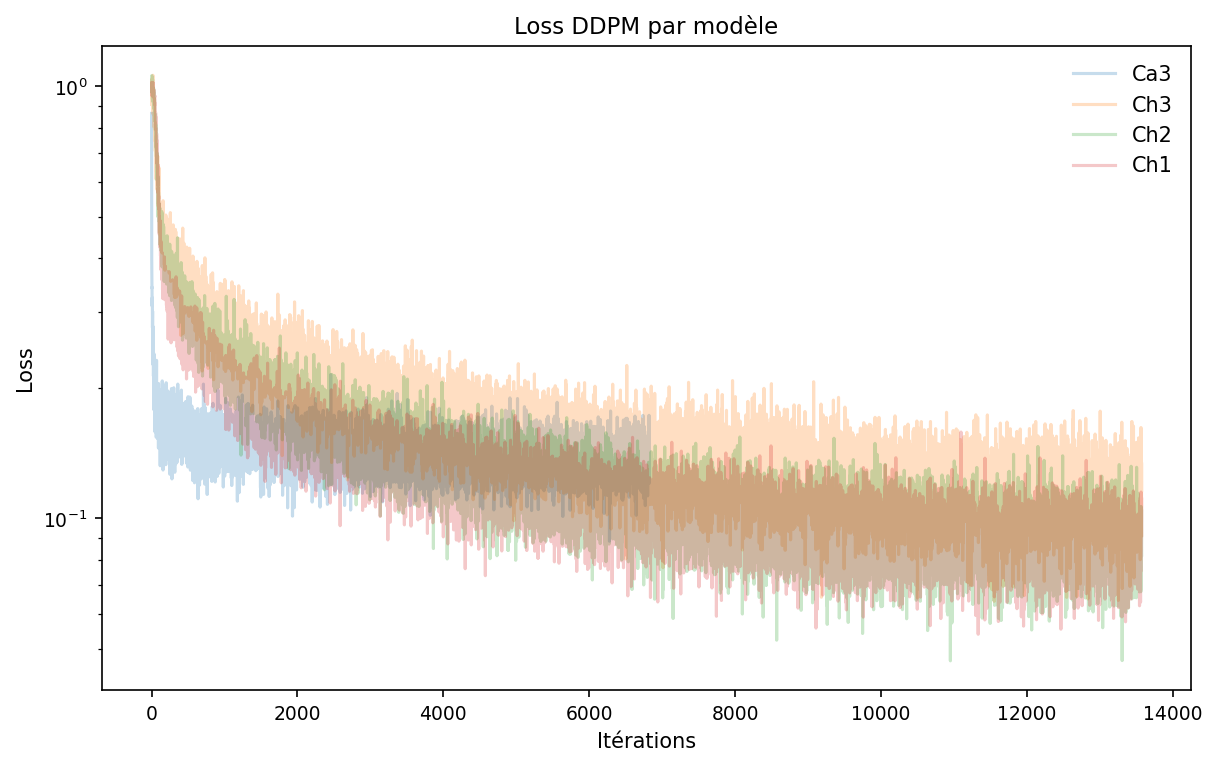

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for name, history in loss_histories.items():
    ax.plot(history, label=name, alpha=0.25)
ax.set_yscale("log")
ax.set_ylabel("Loss")
ax.set_xlabel("Itérations")
ax.set_title("Loss DDPM par modèle")
ax.legend(frameon=False)
plt.show()


# Génération hiérarchique et test

La génération suit exactement l'ordre demandé :

`Ca3` non conditionné → `Ch3 | Ca3` → reconstruction `Ca2` → `Ch2 | Ca2` → reconstruction `Ca1` → `Ch1 | Ca1` → reconstruction du signal.

In [53]:
def sample_reverse(model, target_dim, steps, condition=None, count=None, return_history=False):
    device = next(model.parameters()).device
    dtype = next(model.parameters()).dtype
    was_training = model.training
    model.eval()

    if condition is not None:
        condition = condition.to(device=device, dtype=dtype)
        count = condition.shape[0]
    elif count is None:
        raise ValueError("count doit être fourni pour un sampling non conditionné.")

    betas, alphas, alpha_bars = get_schedule(
        steps,
        device=device,
        dtype=dtype,
    )

    sample_history = []
    with torch.inference_mode():
        xt = torch.randn(count, target_dim, device=device, dtype=dtype)
        if return_history:
            sample_history.append(xt.detach().cpu())

        for step in range(steps, 0, -1):
            t = torch.full((count, 1), step, device=device, dtype=torch.long)
            features = compute_features(xt, t, steps, condition)
            eps_pred = model(features)

            beta_t = betas[step - 1]
            alpha_t = alphas[step - 1]
            alpha_bar_t = alpha_bars[step - 1]

            mean = (xt - beta_t / torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_t)

            if step > 1:
                alpha_bar_prev = alpha_bars[step - 2]
                posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
                xt = mean + torch.sqrt(posterior_var) * torch.randn_like(xt)
            else:
                xt = mean

            if return_history:
                sample_history.append(xt.detach().cpu())

    if was_training:
        model.train()

    if return_history:
        return torch.stack(sample_history)
    return xt.detach().cpu()


def sample_wavelet_cascade(models, count, steps, non_conditioned_steps=T_non_conditione):
    generated_ca3 = sample_reverse(
        models["Ca3"],
        target_dim=Ca3.shape[1],
        steps=non_conditioned_steps,
        count=count,
    )
    generated_ca3 = generated_ca3 * (Ca3_std + 1e-8) + Ca3_mean

    generated_ch3 = sample_reverse(models["Ch3"], target_dim=Ch3.shape[1], steps=steps, condition=generated_ca3)
    generated_ca2 = idwt_pair(generated_ca3, generated_ch3, wavelet=WAVELET)

    generated_ch2 = sample_reverse(models["Ch2"], target_dim=Ch2.shape[1], steps=steps, condition=generated_ca2)
    generated_ca1 = idwt_pair(generated_ca2, generated_ch2, wavelet=WAVELET)

    generated_ch1 = sample_reverse(models["Ch1"], target_dim=Ch1.shape[1], steps=steps, condition=generated_ca1)
    generated_signals = idwt_pair(generated_ca1, generated_ch1, wavelet=WAVELET)[:, :SIGNAL_SIZE]

    return {
        "Ca3": generated_ca3.contiguous(),
        "Ch3": generated_ch3.contiguous(),
        "Ca2": generated_ca2.contiguous(),
        "Ch2": generated_ch2.contiguous(),
        "Ca1": generated_ca1.contiguous(),
        "Ch1": generated_ch1.contiguous(),
        "signals": generated_signals.contiguous(),
    }


GENERATED_BLOCKS = ("Ca3", "Ch3", "Ca2", "Ch2", "Ca1", "Ch1", "signals")


def _generated_shapes(count):
    return {
        "Ca3": (count, Ca3.shape[1]),
        "Ch3": (count, Ch3.shape[1]),
        "Ca2": (count, Ca2.shape[1]),
        "Ch2": (count, Ch2.shape[1]),
        "Ca1": (count, Ca1.shape[1]),
        "Ch1": (count, Ch1.shape[1]),
        "signals": (count, SIGNAL_SIZE),
    }


def load_generated_cascade(output_dir, mmap_mode="r+"):
    output_dir = Path(output_dir)
    generated = {}
    for name in GENERATED_BLOCKS:
        array = np.load(output_dir / f"{name}.npy", mmap_mode=mmap_mode)
        generated[name] = torch.from_numpy(array)
    return generated


def sample_wavelet_cascade_to_disk(
    models,
    count,
    steps,
    output_dir,
    batch_size=512,
    non_conditioned_steps=T_non_conditione,
    overwrite=True,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mode = "w+" if overwrite else "r+"
    arrays = {
        name: np.lib.format.open_memmap(
            output_dir / f"{name}.npy",
            mode=mode,
            dtype=np.float32,
            shape=shape,
        )
        for name, shape in _generated_shapes(count).items()
    }

    for start in tqdm(range(0, count, batch_size), desc="Generation sur disque"):
        end = min(start + batch_size, count)
        chunk = sample_wavelet_cascade(
            models,
            count=end - start,
            steps=steps,
            non_conditioned_steps=non_conditioned_steps,
        )

        for name, values in chunk.items():
            arrays[name][start:end] = values.detach().cpu().to(torch.float32).numpy()
            arrays[name].flush()

        del chunk
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del arrays
    return load_generated_cascade(output_dir)


def tensor_batch_iterator(x, batch_size=8192):
    for start in range(0, len(x), batch_size):
        yield x[start:start + batch_size]


def tensor_mean(x, batch_size=8192, dtype=torch.float64):
    total = None
    n_total = 0
    for batch in tensor_batch_iterator(x, batch_size=batch_size):
        batch = torch.as_tensor(batch).detach().cpu().to(dtype=dtype)
        total = batch.sum(dim=0) if total is None else total + batch.sum(dim=0)
        n_total += batch.shape[0]
    return (total / n_total).to(dtype=torch.float32)


def tensor_mean_and_cov(x, batch_size=8192):
    sum_x = None
    sum_xx = None
    n_total = 0

    for batch in tensor_batch_iterator(x, batch_size=batch_size):
        batch = torch.as_tensor(batch).detach().cpu().to(dtype=torch.float64)
        sum_x = batch.sum(dim=0) if sum_x is None else sum_x + batch.sum(dim=0)
        sum_xx = batch.T @ batch if sum_xx is None else sum_xx + batch.T @ batch
        n_total += batch.shape[0]

    mean = sum_x / n_total
    if n_total > 1:
        cov = (sum_xx - n_total * torch.outer(mean, mean)) / (n_total - 1)
    else:
        cov = torch.zeros((mean.numel(), mean.numel()), dtype=torch.float64)
    return mean.numpy(), cov.numpy()


In [63]:
num_generated = 5000
GENERATION_BATCH_SIZE = 512
GENERATED_OUTPUT_DIR = Path("generated_data") / f"wavelet_cascade_Tcond{T}_Tnoncond{T_non_conditione}_snr{SNR_THRESHOLD:g}_N{num_generated}"

generated = sample_wavelet_cascade_to_disk(
    models,
    count=num_generated,
    steps=T,
    output_dir=GENERATED_OUTPUT_DIR,
    batch_size=GENERATION_BATCH_SIZE,
    non_conditioned_steps=T_non_conditione,
    overwrite=True,
)
generated_signals = generated["signals"]

num_reference = min(num_generated, len(dataset))
original_signals = dataset[:num_reference]

# Baselines de reconstruction exacte avec les coefficients réels tronqués au même nombre d'échantillons.
exact_reconstructed_signals = waverec_tensor(
    [Ca3[:num_reference], Ch3[:num_reference], Ch2[:num_reference], Ch1[:num_reference]],
    wavelet=WAVELET,
    length=SIGNAL_SIZE,
)

exact_rmse = torch.mean((exact_reconstructed_signals - original_signals.cpu()) ** 2).sqrt()
generated_distribution_rmse = torch.mean(
    (tensor_mean(generated_signals) - tensor_mean(original_signals)) ** 2
).sqrt()

print("Reconstruction inverse exacte RMSE                 =", exact_rmse.item())
print("RMSE des moyennes générée/originale               =", generated_distribution_rmse.item())
print("generated_signals.shape                           =", generated_signals.shape)
print("Données générées sauvegardées dans                =", GENERATED_OUTPUT_DIR)


Generation sur disque: 100%|██████████| 10/10 [00:53<00:00,  5.33s/it]

Reconstruction inverse exacte RMSE                 = 1.1433493085633017e-07
RMSE des moyennes générée/originale               = 0.043322209268808365
generated_signals.shape                           = torch.Size([5000, 32])
Données générées sauvegardées dans                = generated_data/wavelet_cascade_Tcond39_Tnoncond200_snr5_N5000


# Faux FID

Ici le FID n'est pas fait dans un espace latent car l'espace d'origine est suffisament petit donc c´est une sorte de faux FID.
$$
\mathrm{FID}
=
\left\|\mu_r - \mu_g\right\|_2^2
+
\mathrm{Tr}
\left(
\Sigma_r
+
\Sigma_g
-
2\left(\Sigma_r\Sigma_g\right)^{1/2}
\right)
$$

In [64]:
from scipy.linalg import sqrtm
import numpy as np


def compute_fid_terms(real, fake, batch_size=8192):
    mu_real, sigma_real = tensor_mean_and_cov(real, batch_size=batch_size)
    mu_fake, sigma_fake = tensor_mean_and_cov(fake, batch_size=batch_size)

    diff = mu_real - mu_fake
    covmean = sqrtm(sigma_real @ sigma_fake)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    mean_term = diff @ diff
    cov_term = np.trace(sigma_real + sigma_fake - 2 * covmean)
    return float(mean_term), float(cov_term), float(mean_term + cov_term)


def compute_fid(real, fake, batch_size=8192):
    return compute_fid_terms(real, fake, batch_size=batch_size)[-1]


print("FID original Ca3    :", compute_fid(Ca3, Ca3))
print("FID original Ch3    :", compute_fid(Ch3, Ch3))
print("FID original Ch2    :", compute_fid(Ch2, Ch2))
print("FID original Ch1    :", compute_fid(Ch1, Ch1))
print("FID original Signal :", compute_fid(dataset[:num_reference], dataset[:num_reference]))

print("=================")

for name, real_block in [
    ("Ca3", Ca3),
    ("Ch3", Ch3),
    ("Ch2", Ch2),
    ("Ch1", Ch1),
]:
    mean_term, cov_term, fid = compute_fid_terms(real_block, generated[name])
    print(f"FID {name:<4}: {fid:.6g}  mean={mean_term:.6g}  cov={cov_term:.6g}")

mean_term, cov_term, fid = compute_fid_terms(
    dataset[:num_reference],
    generated["signals"],
)
print(f"FID Signal: {fid:.6g}  mean={mean_term:.6g}  cov={cov_term:.6g}")


def train_and_score_ca3_architectures(
    architectures=("residual_mlp", "conv1d"),
    epochs=EPOCHS_NB,
    count=5000,
):
    """Comparaison locale des priors Ca3. A lancer explicitement si tu veux benchmarker conv1d."""
    scores = []
    for architecture in architectures:
        model, history = train_diffusion_model(
            f"Ca3_non_conditionné_compare_{architecture}",
            Ca3_train,
            T=T_non_conditione,
            condition=None,
            epochs=epochs,
            batch_size=512,
            lr=5e-4,
            architecture=architecture,
            hidden_dim=256,
        )
        sampled = sample_reverse(
            model,
            target_dim=Ca3.shape[1],
            steps=T_non_conditione,
            count=count,
        )
        sampled = sampled * (Ca3_std + 1e-8) + Ca3_mean
        mean_term, cov_term, fid = compute_fid_terms(Ca3, sampled)
        scores.append({
            "architecture": architecture,
            "fid": fid,
            "mean_term": mean_term,
            "cov_term": cov_term,
            "last_loss": history[-1] if len(history) else np.nan,
        })
    return scores

# Exemple volontairement non exécuté automatiquement :
# train_and_score_ca3_architectures(architectures=("residual_mlp", "conv1d"), epochs=EPOCHS_NB)


FID original Ca3    : -2.007283228522283e-13
FID original Ch3    : 5.440092820663267e-15
FID original Ch2    : -1.942890293094024e-16
FID original Ch1    : 3.469446951953614e-16
FID original Signal : -6.055156376305604e-13
FID Ca3 : 0.0483206  mean=0.037345  cov=0.0109756
FID Ch3 : 0.115113  mean=0.0346674  cov=0.0804455
FID Ch2 : 0.0840901  mean=0.0141294  cov=0.0699607
FID Ch1 : 0.100189  mean=0.00707041  cov=0.0931186
FID Signal: 0.429083  mean=0.060058  cov=0.369025


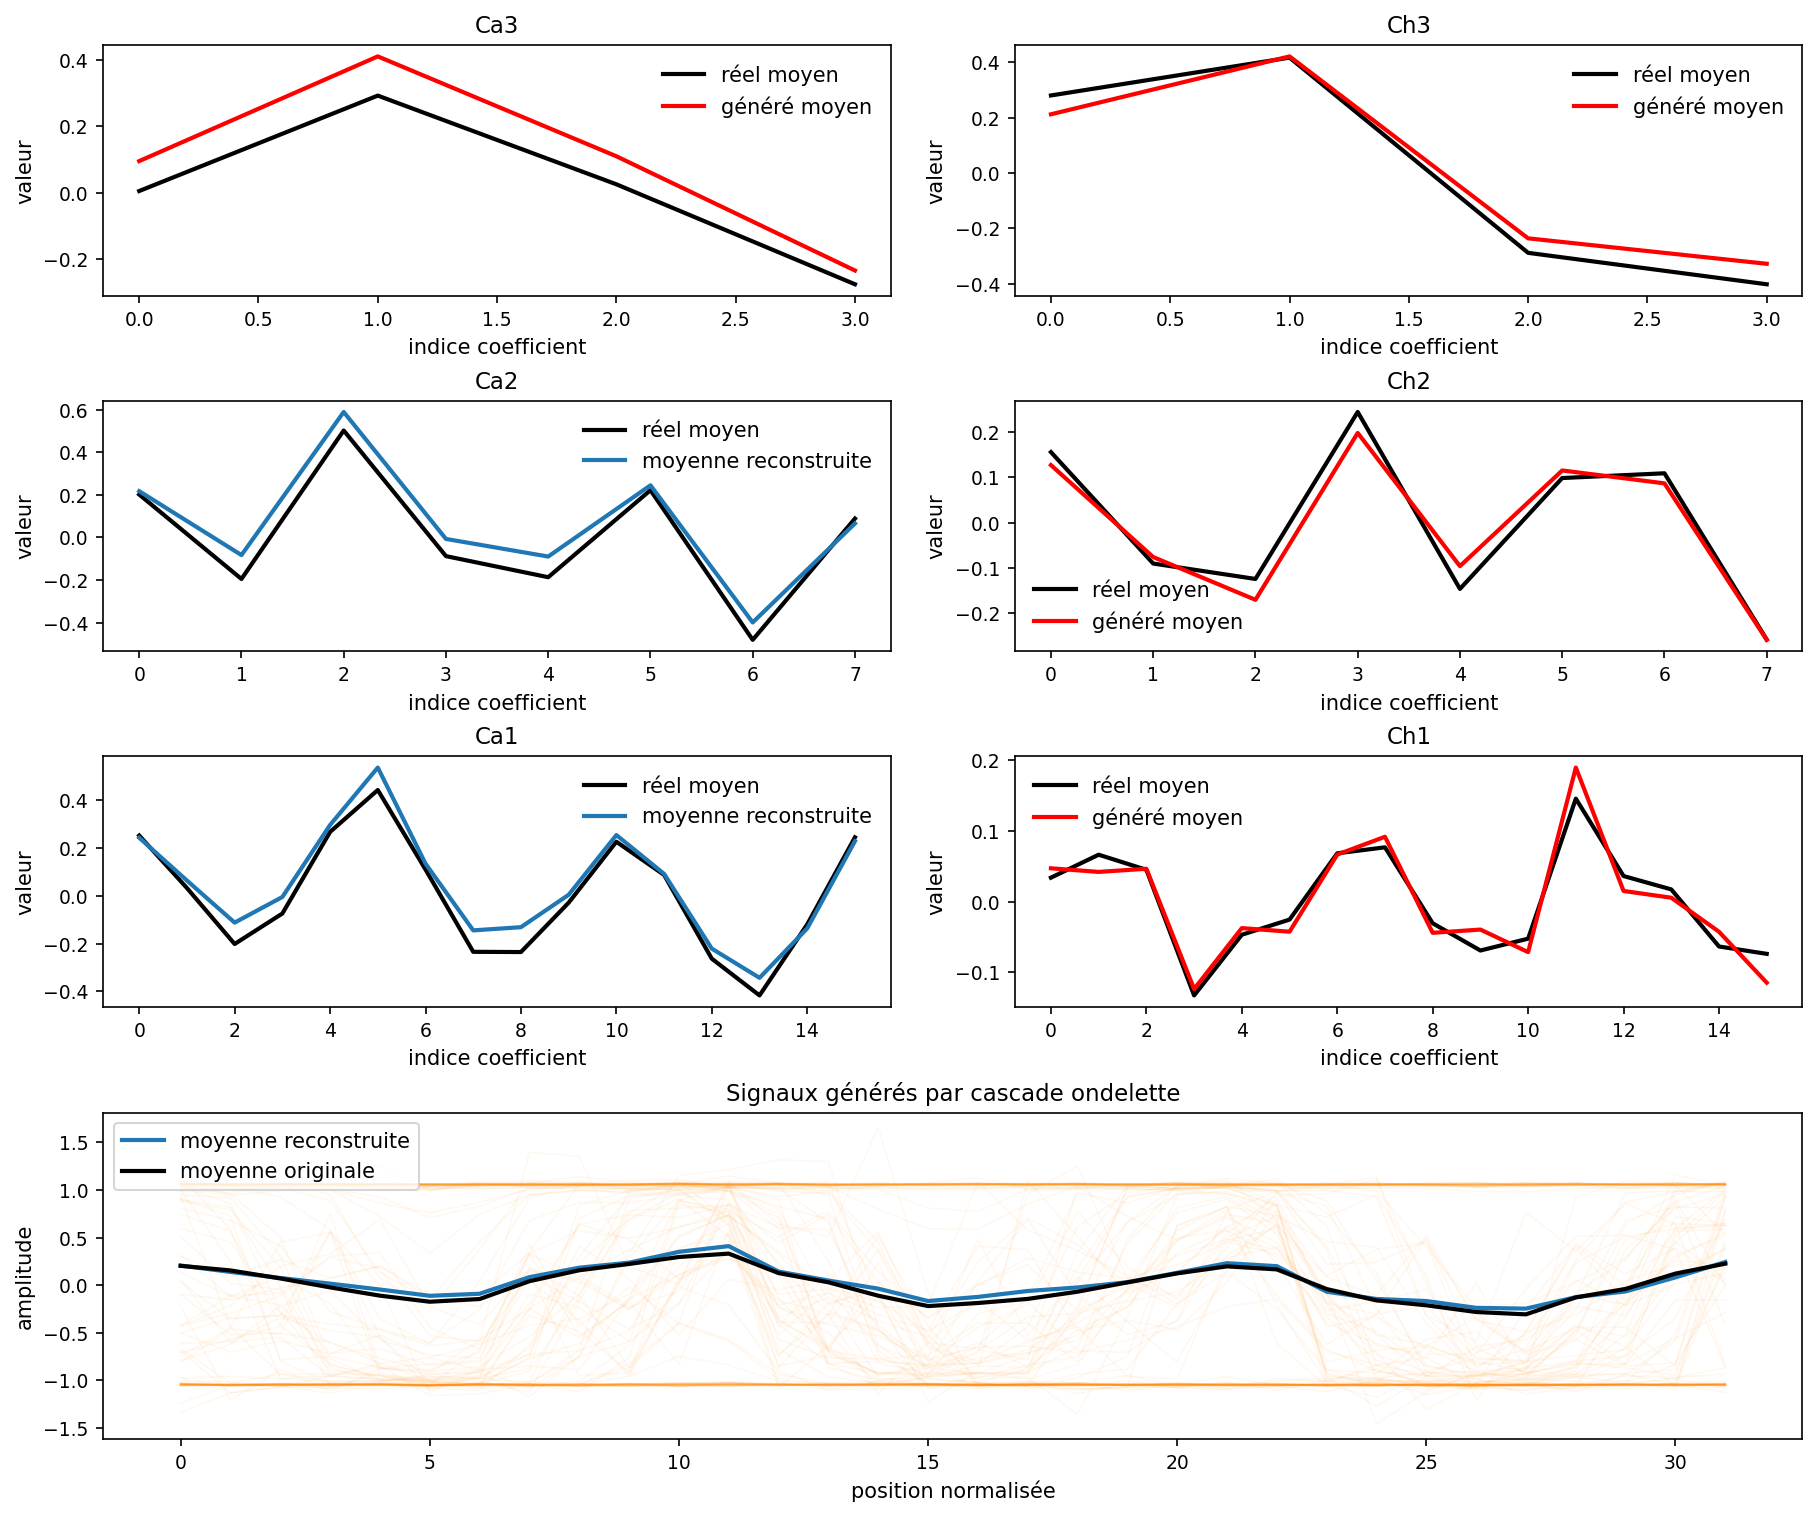

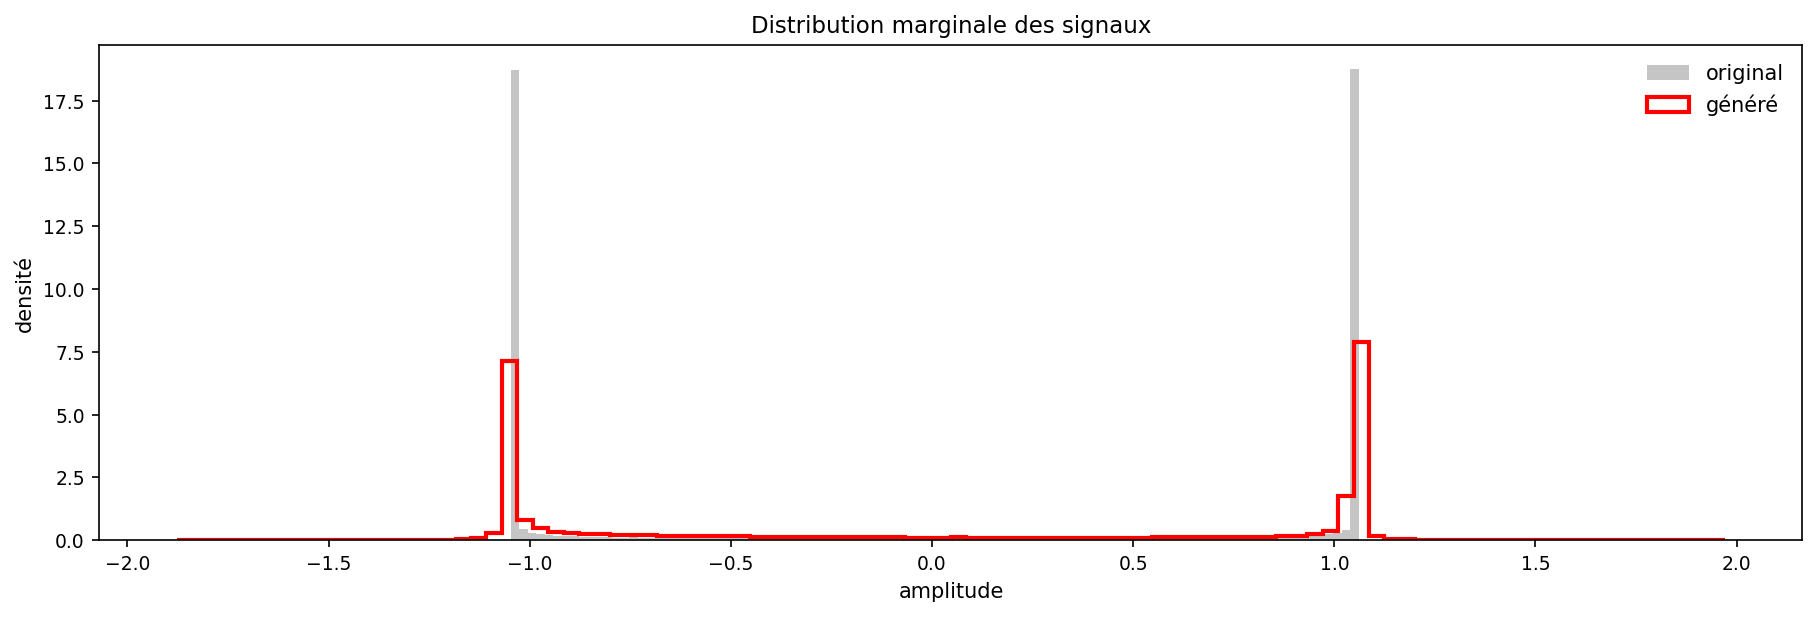

In [65]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

plot_count = min(120, len(generated_signals))
hist_count = min(5000, len(generated_signals))

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(4, 2, height_ratios=[1.0, 1.0, 1.0, 1.3])

ax_all = fig.add_subplot(gs[3, :])
ax_blocks = [fig.add_subplot(gs[i, j]) for i in range(0, 3) for j in range(2)]

signal_grid = torch.arange(generated_signals.shape[1])
ax_all.plot(signal_grid, generated_signals[:plot_count].T, color="darkorange", alpha=0.06, linewidth=0.8)
ax_all.plot(signal_grid, tensor_mean(generated_signals), color="tab:blue", linewidth=2, label="moyenne reconstruite")
ax_all.plot(signal_grid, tensor_mean(original_signals), color="black", linewidth=2, label="moyenne originale")
ax_all.set_title("Signaux générés par cascade ondelette")
ax_all.set_xlabel("position normalisée")
ax_all.set_ylabel("amplitude")
ax_all.legend(loc="upper left")

for axis, name, real_block in zip(
    ax_blocks,
    ["Ca3", "Ch3", "Ca2", "Ch2", "Ca1", "Ch1"],
    [Ca3, Ch3, Ca2, Ch2, Ca1, Ch1],
):
    fake_block = generated[name]
    coef_grid = torch.arange(real_block.shape[1])
    axis.plot(coef_grid, tensor_mean(real_block[:num_reference]), color="black", linewidth=2, label="réel moyen")
    if name in ["Ca2", "Ca1"]:
        color = "tab:blue"
        label = "moyenne reconstruite"
    else:
        color = "red"
        label = "généré moyen"

    axis.plot(coef_grid, tensor_mean(fake_block), color=color, linewidth=2, label=label)
    axis.set_title(name)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")
    axis.legend(frameon=False)

plt.savefig("500-epochs-generated_signals_and_coefficients.png", dpi=150)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
ax.hist(original_signals[:hist_count].flatten(), bins=100, density=True, color="gray", alpha=0.45, label="original")
ax.hist(generated_signals[:hist_count].flatten(), bins=100, density=True, histtype="step", linewidth=2, color="red", label="généré")
ax.set_title("Distribution marginale des signaux")
ax.set_xlabel("amplitude")
ax.set_ylabel("densité")
ax.legend(frameon=False)

plt.savefig("500-epochs-generated_signals_distribution.png", dpi=150)
plt.show()


# Attention - Fausse comparaison !

Comme le premier model qui estime $C_a$ n'est pas conditionnée les signaux génerés ne le sont pas non plus. Le plot suivant montre alors non pas un equivalent mais le plus proche voisin du jeux de base.

$$ x^*_{reel} = \arg \min_i||x_{generated} - x_i||_2 $$

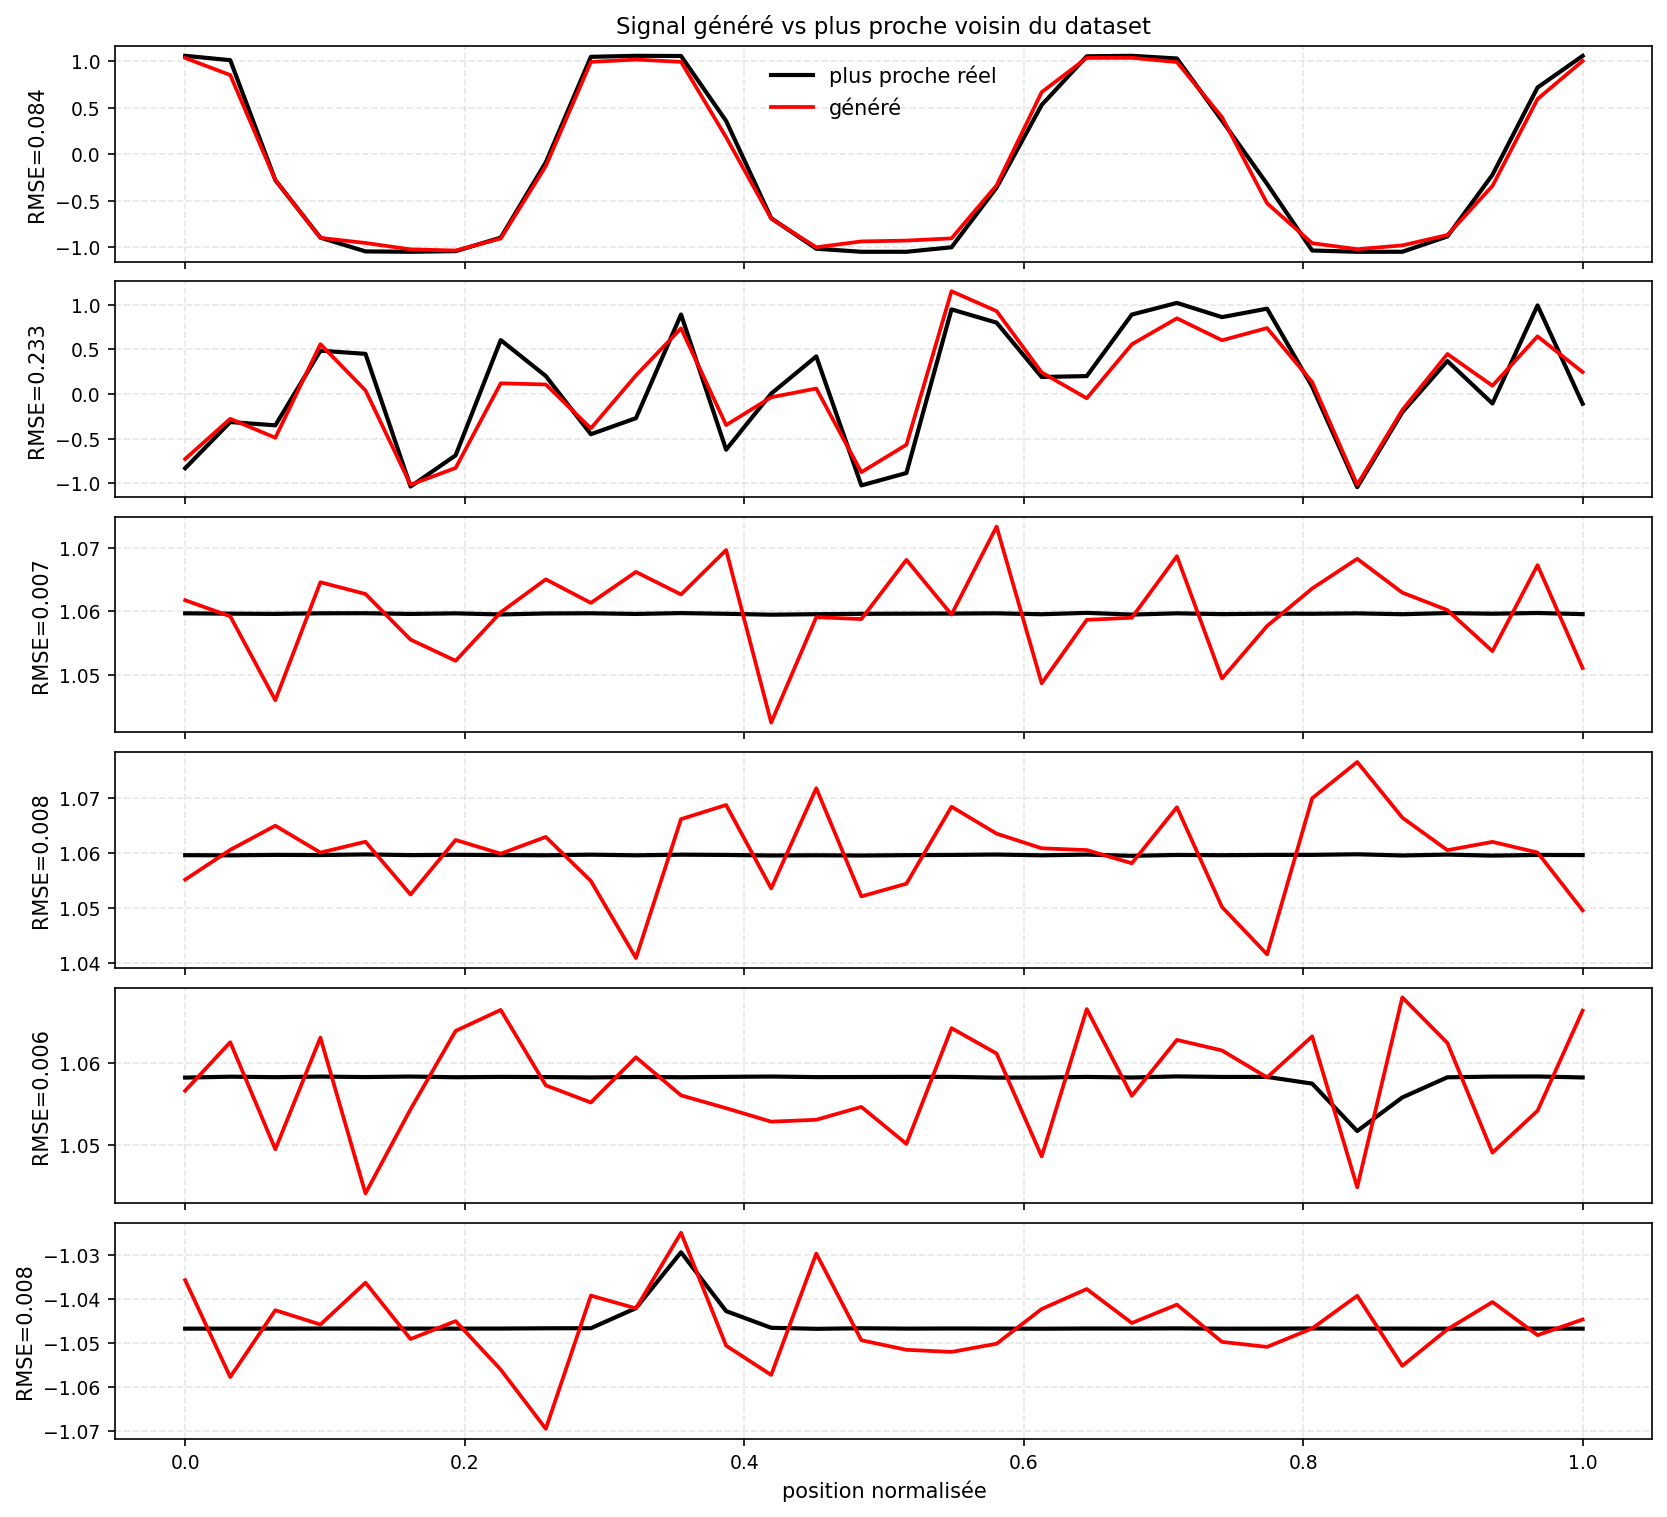

In [67]:
def plot_nearest_neighbors(
    generated_signals,
    dataset,
    n_examples=6,
):
    example_ids = torch.linspace(
        0,
        len(generated_signals) - 1,
        n_examples,
    ).long()

    signal_grid = torch.linspace(
        0,
        1,
        generated_signals.shape[1],
    )

    fig, axes = plt.subplots(
        n_examples,
        1,
        figsize=(11, 10),
        sharex=True,
        constrained_layout=True,
    )

    if n_examples == 1:
        axes = [axes]

    for axis, idx in zip(axes, example_ids):
        idx = int(idx.item())

        generated = generated_signals[idx]

        distances = torch.mean(
            (dataset - generated[None, :])**2,
            dim=1,
        )

        nearest_idx = torch.argmin(distances)

        nearest_real = dataset[nearest_idx]

        rmse = torch.sqrt(
            distances[nearest_idx]
        )

        axis.plot(
            signal_grid,
            nearest_real,
            color="black",
            linewidth=2,
            label="plus proche réel",
        )

        axis.plot(
            signal_grid,
            generated,
            color="red",
            linewidth=1.8,
            label="généré",
        )

        axis.set_ylabel(
            f"RMSE={rmse:.3f}"
        )


        axis.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

    axes[0].set_title(
        "Signal généré vs plus proche voisin du dataset"
    )

    axes[0].legend(
        frameon=False,
    )

    axes[-1].set_xlabel(
        "position normalisée"
    )

    plt.show()

plot_nearest_neighbors(
    generated_signals,
    dataset,
)

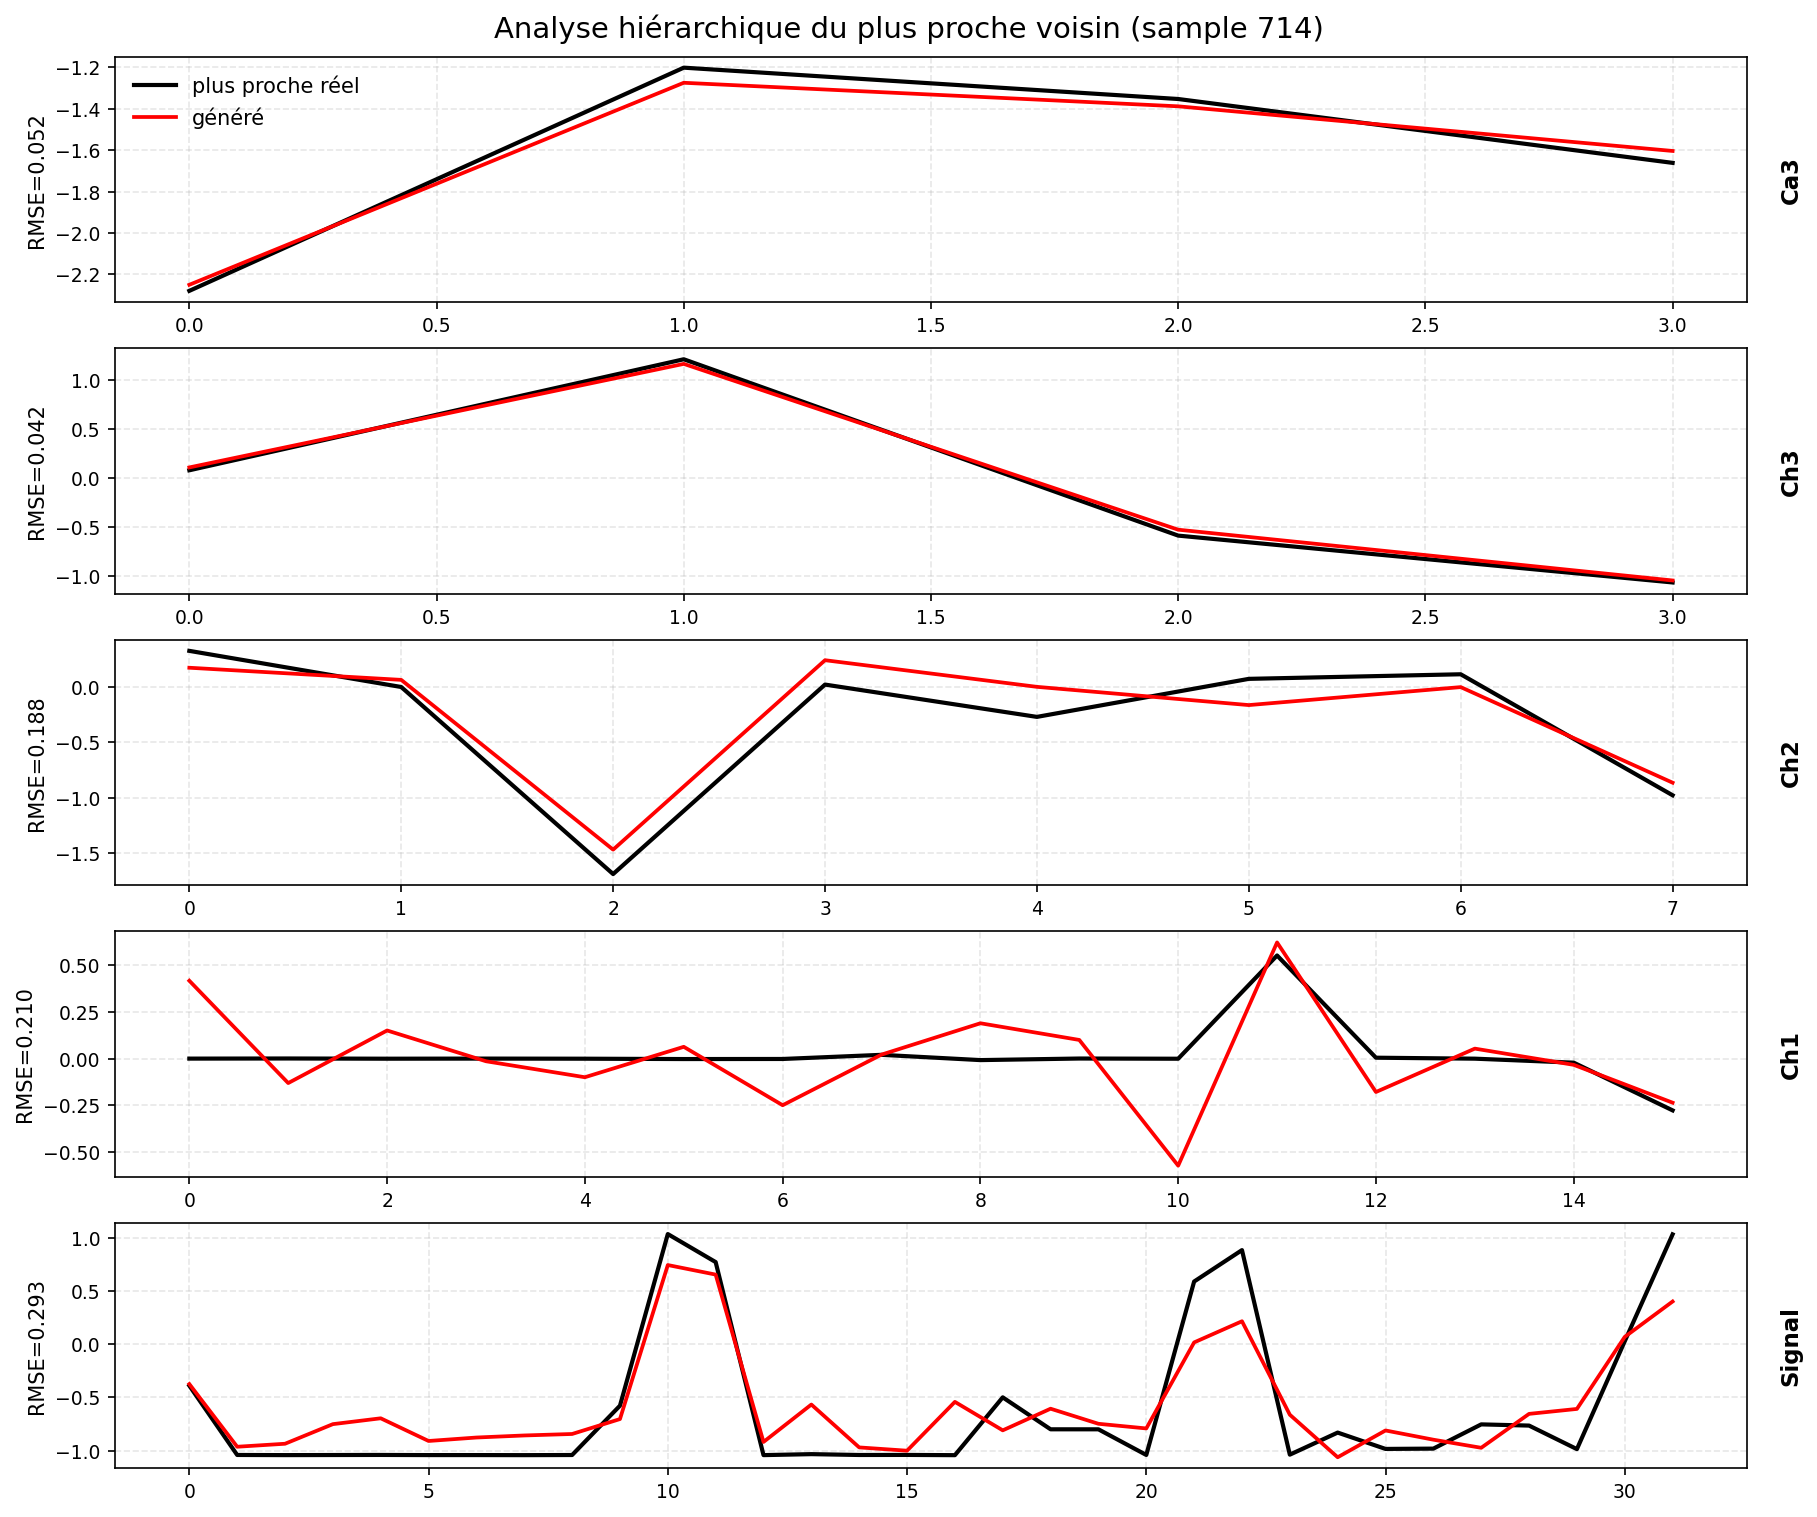

In [71]:
def plot_hierarchy_nearest_neighbor(
    generated,
    dataset,
    Ca3,
    Ch3,
    Ch2,
    Ch1,
    sample_idx=0,
):
    levels = [
        ("Ca3", generated["Ca3"], Ca3),
        ("Ch3", generated["Ch3"], Ch3),
        ("Ch2", generated["Ch2"], Ch2),
        ("Ch1", generated["Ch1"], Ch1),
        ("Signal", generated["signals"], dataset),
    ]

    fig, axes = plt.subplots(
        len(levels),
        1,
        figsize=(12, 10),
        constrained_layout=True,
    )

    for axis, (name, generated_block, real_block) in zip(axes, levels):

        generated_sample = generated_block[sample_idx]

        distances = torch.mean(
            (real_block - generated_sample[None, :]) ** 2,
            dim=1,
        )

        nearest_idx = torch.argmin(distances)

        nearest_real = real_block[nearest_idx]

        rmse = torch.sqrt(distances[nearest_idx]).item()

        x = torch.arange(len(generated_sample))

        axis.plot(
            x,
            nearest_real,
            color="black",
            linewidth=2,
            label="plus proche réel",
        )

        axis.plot(
            x,
            generated_sample,
            color="red",
            linewidth=1.8,
            label="généré",
        )

        axis.set_ylabel(
            f"RMSE={rmse:.3f}"
        )

        axis.text(
            1.02,
            0.5,
            name,
            transform=axis.transAxes,
            rotation=90,
            va="center",
            ha="left",
            fontsize=11,
            fontweight="bold",
        )

        axis.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

    axes[0].legend(frameon=False)

    fig.suptitle(
        f"Analyse hiérarchique du plus proche voisin (sample {sample_idx})",
        fontsize=14,
    )

    plt.show()


rand_sample_idx = np.random.randint(0, generated_signals.shape[0])

plot_hierarchy_nearest_neighbor(
    generated,
    dataset,
    Ca3,
    Ch3,
    Ch2,
    Ch1,
    rand_sample_idx
)